# 13 · Discrete-event simulation

When closed forms run out - time-varying arrivals, abandonment, priorities, finite populations, inventory
policies - we simulate. A discrete-event simulation jumps from event to event, keeps a future-event list, and
updates statistics as it goes. This notebook builds models on a 60-line engine: a multi-server queue with
impatient customers, a machine-repair shop, and an (s, S) inventory system whose policy we optimise.

**What you will learn**
- build an event-scheduling simulation with an event list and statistics
- model abandonment, finite sources and inventory policies
- validate a simulation against analytical results
- optimise by simulation without fooling yourself

**Before you start:** notebooks 09-12  ·  **Time:** about 90 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import des, queues as qu, ctmc, montecarlo as mc
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## The engine: clock, event list, statistics

In [2]:
show_source(des.Simulator)

class Simulator:
    """Event-scheduling simulation clock with a future-event list."""

    def __init__(self):
        self.now = 0.0
        self._events: list = []
        self._seq = itertools.count()
        self.n_events = 0

    def schedule(self, time: float, action, *args) -> None:
        """Schedule action(*args) at absolute time `time` (>= now)."""
        if time < self.now - 1e-12:
            raise ValueError("cannot schedule an event in the past")
        heapq.heappush(self._events, (time, next(self._seq), action, args))

    def after(self, delay: float, action, *args) -> None:
        self.schedule(self.now + delay, action, *args)

    def run(self, until: float = math.inf) -> None:
        """Process events in time order until the list is empty or the next event is after `until`."""
        while self._events and self._events[0][0] <= until:
            time, _, action, args = heapq.heappop(self._events)
            self.now = time
            self.n_events += 1
            action(*args)
        if until < math.inf:
            self.now = until

In [3]:
sim = des.Simulator()
trace = []
def customer(k):
    trace.append((round(sim.now, 3), f"customer {k} arrives"))
    sim.after(1.5, lambda: trace.append((round(sim.now, 3), f"customer {k} leaves")))
for k, t in enumerate([0.4, 1.0, 1.2]):
    sim.schedule(t, customer, k)
sim.run()
for row in trace:
    print(row)

(0.4, 'customer 0 arrives')
(1.0, 'customer 1 arrives')
(1.2, 'customer 2 arrives')
(1.9, 'customer 0 leaves')
(2.5, 'customer 1 leaves')
(2.7, 'customer 2 leaves')


The event list is a binary heap ordered by time (with an insertion counter so that simultaneous events are
processed first-in, first-out - otherwise results would depend on the heap's internals). An event is any
callable; executing it may schedule further events. Time-weighted statistics (queue length, busy servers)
integrate a piecewise-constant value between events; tallies average per-customer observations.

## A queue with abandonment

In [4]:
lam, mu, theta = 4.0, 1.0, 0.5
rows = []
for c in (3, 4, 5, 6):
    r = des.call_centre(lambda t: lam, lam, lambda g: g.exponential(1 / mu), c, 20_000.0, R(c), patience_sampler=lambda g: g.exponential(1 / theta), answer_within=0.25, warmup=200.0)
    pi = ctmc.birth_death([lam] * 80, [min(k, c) * mu + max(k - c, 0) * theta for k in range(1, 81)])["stationary"]
    exact = float(np.sum(pi * np.maximum(np.arange(81) - c, 0) * theta) / lam)
    rows.append((c, r["abandon_rate"], exact, r["service_level"], r["mean_busy"] / c))
print(pd.DataFrame(rows, columns=["agents", "abandonment (simulated)", "abandonment (Erlang-A chain)", "answered within 0.25", "occupancy"]).to_string(index=False, float_format="%.4f"))

 agents  abandonment (simulated)  abandonment (Erlang-A chain)  answered within 0.25  occupancy
      3                   0.3037                        0.3068                0.2554     0.9245
      4                   0.1637                        0.1629                0.5087     0.8378
      5                   0.0792                        0.0780                0.7265     0.7413
      6                   0.0357                        0.0342                0.8703     0.6496


Customers who wait longer than an exponential patience hang up. With exponential everything the system is a
birth-death chain whose death rate in state n is min(n, c)μ + (n − c)⁺θ (the Erlang-A model, standard in call
centres), and the event simulation reproduces it. Abandonment stabilises an overloaded system - with 3 agents
and 4 erlangs of load the queue does not explode, a third of the callers simply leave.

## Machine repair: a finite source

In [5]:
rows = []
for repairers in (1, 2, 3):
    for dist, sampler in (("exponential", lambda g: g.exponential(2.0)), ("deterministic", lambda g: 2.0), ("lognormal cv 2", lambda g: g.lognormal(np.log(2.0) - 0.5 * np.log(5), np.sqrt(np.log(5))))):
        r = des.machine_repair(10, repairers, 0.05, sampler, 100_000.0, R(repairers * 10 + len(dist)))
        rows.append((repairers, dist, r["mean_down"], r["availability"]))
bd = ctmc.birth_death([0.05 * (10 - k) for k in range(10)], [min(k, 1) * 0.5 for k in range(1, 11)])
print(pd.DataFrame(rows, columns=["repairers", "repair time", "mean machines down", "availability"]).to_string(index=False, float_format="%.4f"))
print(f"exponential, 1 repairer, from the birth-death chain: mean down {np.dot(np.arange(11), bd['stationary']):.4f}")

 repairers    repair time  mean machines down  availability
         1    exponential              2.0905        0.7909
         1  deterministic              1.8008        0.8199
         1 lognormal cv 2              2.4788        0.7521
         2    exponential              1.0419        0.8958
         2  deterministic              0.9866        0.9013
         2 lognormal cv 2              1.0922        0.8908
         3    exponential              0.9180        0.9082
         3  deterministic              0.9207        0.9079
         3 lognormal cv 2              0.9417        0.9058
exponential, 1 repairer, from the birth-death chain: mean down 2.1458


Ten machines share the repair crew: when many are down, fewer can fail, so the arrival rate to the queue
depends on its length. With a single repairer the distribution of repair times matters (variable repairs
cause long backlogs); as the crew grows, availability approaches the insensitive alternating-renewal value
E[U]/(E[U] + E[D]) = 0.909.

## An inventory policy, optimised by simulation

best (s, S) on the grid with 5 replications each: (6, 31), cost 23.89


vs (12, 25) with common random numbers: difference -3.76, 95 % CI (-3.90, -3.62)


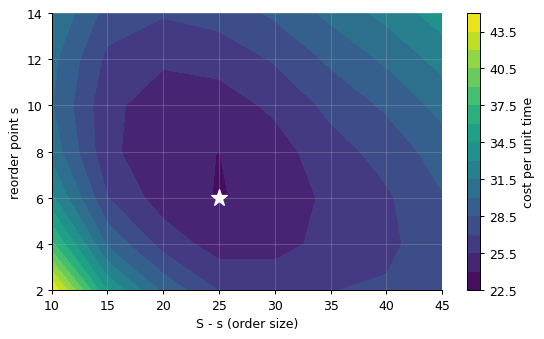

In [6]:
def cost(s, S, seed):
    return des.inventory_sS(s, S, 2.0, lambda g: 1 + g.poisson(1.0), lambda g: g.uniform(1.0, 3.0), 2000.0, R(seed), holding=1.0, shortage=10.0, order_cost=50.0)["cost_rate"]
grid = [(s, S) for s in range(2, 16, 2) for S in range(s + 10, s + 50, 5)]
est = {k: np.mean([cost(*k, seed) for seed in range(5)]) for k in grid}
best = min(est, key=est.get)
print(f"best (s, S) on the grid with 5 replications each: {best}, cost {est[best]:.2f}")
diff = [cost(*best, 100 + k) - cost(12, 25, 100 + k) for k in range(20)]
r = mc.mean_ci(diff, method="t")
print(f"vs (12, 25) with common random numbers: difference {r['estimate']:.2f}, 95 % CI ({r['ci'][0]:.2f}, {r['ci'][1]:.2f})")
S_ = np.array(sorted({k[1] - k[0] for k in grid})); s_ = np.array(sorted({k[0] for k in grid}))
Z = np.array([[est.get((s, s + d), np.nan) for d in S_] for s in s_])
plt.contourf(S_, s_, Z, 20); plt.colorbar(label="cost per unit time"); plt.xlabel("S - s (order size)"); plt.ylabel("reorder point s"); plt.plot(best[1] - best[0], best[0], "w*", ms=14); plt.show()

The reorder point s buys protection against demand during the lead time; the order quantity S − s trades
ordering cost against holding cost (the economic order quantity in disguise). Simulation optimisation needs
care: the minimum over a noisy grid is biased low (the "winner's curse"), so the chosen policy is re-evaluated
with fresh, common random numbers against a competitor before any claim is made.

## Inside the algorithm: an M/M/1 queue in twenty lines

In [7]:
sim = des.Simulator(); g = R(40); state = {"n": 0}; waits = []; queue = []
q_tw = des.TimeWeighted(sim)
def arrive():
    if state["n"] == 0: waits.append(0.0); sim.after(g.exponential(1.0), depart)
    else: queue.append(sim.now)
    state["n"] += 1; q_tw.update(state["n"]); sim.after(g.exponential(1 / 0.8), arrive)
def depart():
    state["n"] -= 1; q_tw.update(state["n"])
    if queue: waits.append(sim.now - queue.pop(0)); sim.after(g.exponential(1.0), depart)
sim.schedule(0.0, arrive); sim.run(until=50_000)
print(f"mean wait {np.mean(waits):.2f} (4), time-average number in system {q_tw.mean():.2f} (4)")

mean wait 3.88 (4), time-average number in system 3.90 (4)


## Exercises
1. Add a callback option to the call-centre model: callers who abandon call back after an exponential time (mean 30 min) with probability 0.5. How much does it raise the load and the abandonment rate at 4 agents?
2. Compare continuous review with periodic review (every 2 time units) in the (s, S) inventory model: optimise each and report the cost difference with a common-random-numbers interval.
3. **Implement it yourself:** add a priority class to the M/M/1 example above (two customer types, non-preemptive priority) and check the mean waits against Cobham's formula.